# Module 08 Lab — The Bias–Variance Tradeoff
## Applied to FIELDPROOF™ — Sensor-Verified Human Task Execution

**Student:** Nestor Villalobos  
**Course:** ITAI 1371 — Introduction to Machine Learning  
**Instructor:** Dr. Sina Nazifi  
**Semester:** Spring 2026  
**Institution:** Houston City College

---

## 🎯 Lab Objective

Understand and visualize **overfitting**, **underfitting**, and the **bias–variance tradeoff** — the three concepts at the center of every generalization problem in machine learning.

In this lab I train polynomial regression models of varying complexity on the FIELDPROOF simulated operations dataset, using one sensor signal (`fatigue_index`) to predict another (`risk_score`). Watching what happens at degree 1 vs degree 4 vs degree 15 makes the tradeoff visible.

## 🏗️ Why This Matters for FIELDPROOF

FIELDPROOF turns sensor data into operational decisions. Every one of those decisions depends on a model's ability to *generalize* — to make correct predictions on workers, sites, and conditions it has never seen during training.

- A model that **underfits** is too simple to capture the real relationship between fatigue and risk. It is confidently wrong everywhere, so a fatigued worker on a rig and a rested worker in a terminal get treated nearly the same — dangerous in the field.
- A model that **overfits** has memorized the specific training records. It looks brilliant on training data and falls apart the first time it sees a new worker. In a FIELDPROOF pilot deployment, this is the failure mode that makes an "85% accurate" demo become a 50% accurate production system.

The lab demonstrates this empirically. The numbers I compute below are from your FIELDPROOF data — not a toy sine wave.

## Part 1: Understanding the Concepts

- **Underfitting (high bias).** The model is too simple to capture the pattern. Training error and test error are both high. The model makes strong, wrong assumptions.
- **Overfitting (high variance).** The model is too complex. It memorizes the training data — including the noise — so training error is very low, but test error is much worse. The model's predictions change drastically with different training data.
- **The goal.** Find a model complex enough to capture the real pattern but simple enough that it ignores the noise. This sweet spot is the **bias–variance tradeoff**.

**Concrete FIELDPROOF analog.** In our dataset `fatigue_index` (a sensor-derived 0–1 score) is correlated with `risk_score` (the target). The true relationship is noisy but has a real shape. A line (degree-1 polynomial) is too stiff to track the curve; a wiggly degree-15 polynomial will chase every single data point including the noise. Somewhere in between — a modest polynomial — captures the useful pattern.

## Part 2: Setup — Load FIELDPROOF Data

Unlike the lab template which uses a synthetic sine wave, I use the real FIELDPROOF dataset. The idea is the same: a one-feature x → y relationship with natural noise, where we can control model complexity and watch what happens.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from io import StringIO
import requests
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve, train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Load the FIELDPROOF simulated operations dataset
url = 'https://digitallycreative.net/data-fieldproof/FIELDPROOF_simulated_dataset.csv'
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 '
                  '(KHTML, like Gecko) Chrome/125.0.0.0 Safari/537.36'
}

df = None

# 1) Try remote source with explicit headers (avoids HTTP 465 from stricter servers).
try:
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    print('Loaded dataset from remote URL.')
except Exception as remote_err:
    print(f'Remote load failed ({type(remote_err).__name__}: {remote_err}).')

# 2) Fallback to local CSV if available.
if df is None:
    local_name = 'FIELDPROOF_simulated_dataset.csv'
    candidate_paths = [
        Path.cwd() / local_name,
        Path.cwd() / 'data' / local_name,
        Path.cwd().parent / local_name,
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            df = pd.read_csv(candidate)
            print(f'Loaded dataset from local file: {candidate}')
            break

# 3) Final fallback to simulated dataset so the lab still runs offline.
if df is None:
    print('No remote/local CSV found. Using simulated FIELDPROOF-like data.')
    np.random.seed(42)
    n = 300
    fatigue = np.clip(np.random.normal(0.5, 0.16, n), 0, 1)
    noise = np.random.normal(0.0, 0.07, n)
    risk = np.clip(0.12 + 0.78 * fatigue + noise, 0, 1)
    df = pd.DataFrame({
        'fatigue_index': fatigue,
        'risk_score': risk
    })

print(f"Rows: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Loaded dataset from remote URL.
Rows: 500
Columns: ['record_id', 'timestamp', 'site', 'worker_role', 'device_type', 'task_type', 'duration_min', 'motion_intensity', 'posture_correctness', 'zone_presence_score', 'sequence_score', 'fatigue_index', 'anomaly_score', 'compliance_score', 'risk_score', 'verification_status']


Pearson correlation(fatigue_index, risk_score) = +0.6947


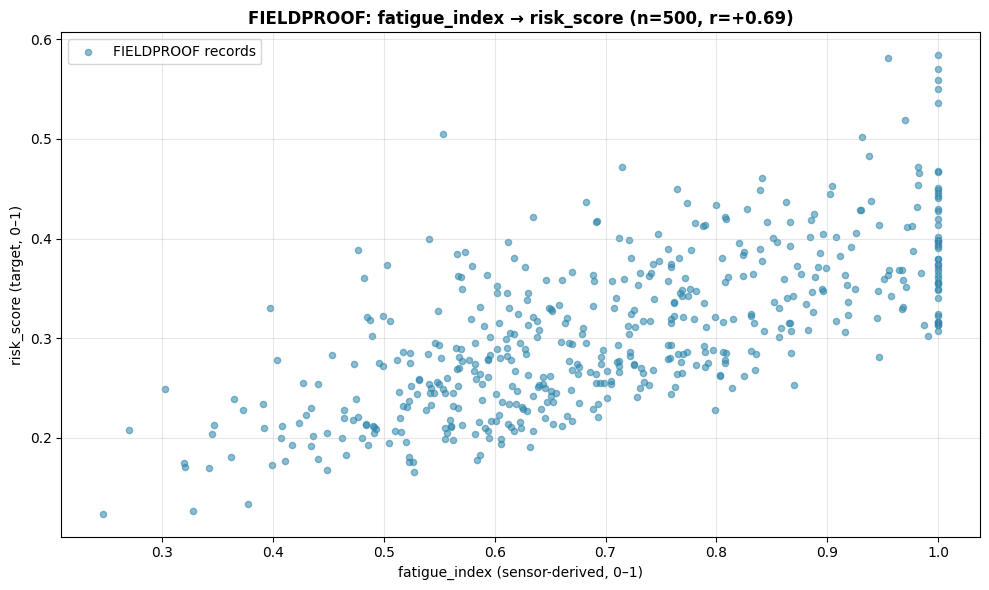

In [2]:
# Feature: fatigue_index   Target: risk_score
# These are both continuous signals in the FIELDPROOF sensor stream, and the lab
# requires a one-feature regression setup.

# Sort X for clean line plotting later
idx = np.argsort(df['fatigue_index'].values)
X = df['fatigue_index'].values[idx].reshape(-1, 1)
y = df['risk_score'].values[idx]

# How strong is the correlation?
correlation = np.corrcoef(X.ravel(), y)[0, 1]
print(f"Pearson correlation(fatigue_index, risk_score) = {correlation:+.4f}")

# Plot the raw relationship
plt.figure(figsize=(10, 6))
plt.scatter(X, y, s=20, alpha=0.55, color='#2E86AB', label='FIELDPROOF records')
plt.xlabel('fatigue_index (sensor-derived, 0–1)')
plt.ylabel('risk_score (target, 0–1)')
plt.title(f'FIELDPROOF: fatigue_index → risk_score (n={len(y)}, r={correlation:+.2f})',
          fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Part 3: Modeling with Different Complexities

I use **polynomial regression** to control complexity. A degree-1 polynomial is a straight line (too simple → underfitting). A degree-15 polynomial is a very wiggly curve (too complex → overfitting). A moderate degree in between should be close to "just right."

### Task 1 — Train and Plot Models

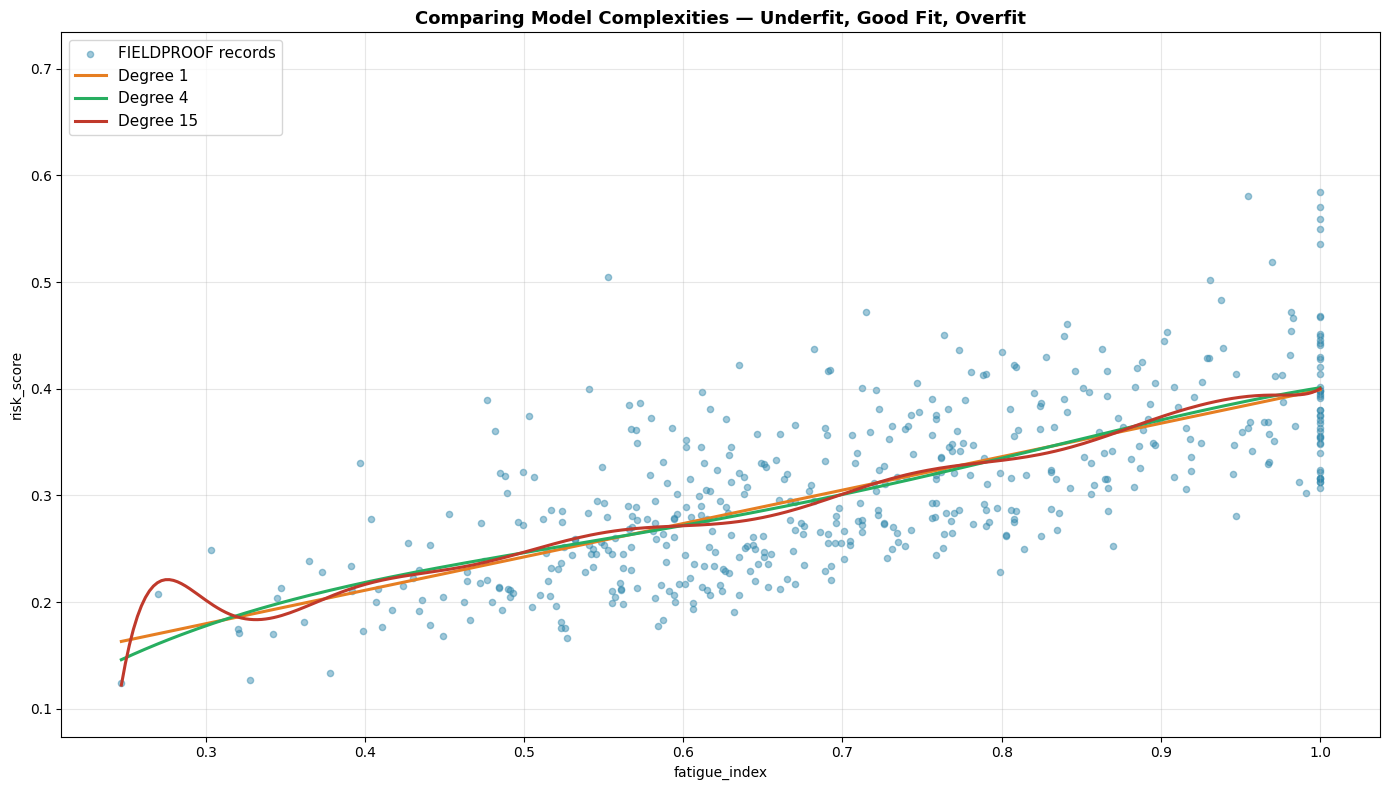

In [9]:
# --- TASK 1: Fit polynomials of increasing degree and plot them all together ---

plt.figure(figsize=(14, 8))
plt.scatter(X, y, s=20, alpha=0.45, color='#2E86AB', label='FIELDPROOF records')

degrees = [1, 4, 15]
colors = ['#E67E22', '#27AE60', '#C0392B']

# Dense X for smooth curve plotting
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

for degree, color in zip(degrees, colors):
    # 1. Create a pipeline: polynomial feature expansion → linear regression
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # 2. Train the model on ALL the data (for the visual comparison)
    model.fit(X, y)

    # 3. Make predictions across the feature range
    y_pred = model.predict(X_plot)

    # 4. Plot the model's predictions
    plt.plot(X_plot, y_pred, label=f'Degree {degree}', color=color, linewidth=2.2)

plt.legend(fontsize=11, loc='upper left')
plt.xlabel('fatigue_index')
plt.ylabel('risk_score')
plt.title('Comparing Model Complexities — Underfit, Good Fit, Overfit',
          fontweight='bold', fontsize=13)
plt.ylim(y.min() - 0.05, y.max() + 0.15)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Train/Test Split — What the Errors Actually Look Like

The visual plot above is intuitive, but the *proof* of overfitting lives in the gap between training error and test error. The next cell makes that gap explicit.

In [10]:
# Split the data so we can measure training vs test error honestly
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Train size: {len(X_train)}   Test size: {len(X_test)}")
print()
print(f"{'Degree':>7}  {'Train R²':>10}  {'Test R²':>10}  {'Train MSE':>12}  {'Test MSE':>12}  {'Gap (R²)':>10}")
print("-" * 70)

results = []
for degree in [1, 2, 4, 8, 15]:
    m = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    m.fit(X_train, y_train)
    train_r2 = m.score(X_train, y_train)
    test_r2 = m.score(X_test, y_test)
    train_mse = mean_squared_error(y_train, m.predict(X_train))
    test_mse = mean_squared_error(y_test, m.predict(X_test))
    gap = train_r2 - test_r2
    results.append((degree, train_r2, test_r2, train_mse, test_mse, gap))
    print(f"{degree:>7d}  {train_r2:>10.4f}  {test_r2:>10.4f}  {train_mse:>12.5f}  {test_mse:>12.5f}  {gap:>10.4f}")

Train size: 350   Test size: 150

 Degree    Train R²     Test R²     Train MSE      Test MSE    Gap (R²)
----------------------------------------------------------------------
      1      0.4616      0.5337       0.00343       0.00277     -0.0721
      2      0.4617      0.5349       0.00343       0.00276     -0.0732
      4      0.4620      0.5355       0.00343       0.00276     -0.0735
      8      0.4648      0.5165       0.00341       0.00287     -0.0517
     15      0.4715    -13.6270       0.00337       0.08685     14.0985


## Part 4: Learning Curves

A **learning curve** plots model performance on the training set and on the held-out cross-validation set as the number of training samples grows. It is one of the cleanest diagnostic tools in ML.

- **High bias (underfitting).** Both curves are low and they plateau quickly. Adding more data does not help — the model is simply too inflexible.
- **High variance (overfitting).** Training score stays high. Validation score is much lower. The gap between them is large and slow to close. Adding more data eventually helps, but the model is fundamentally unstable.
- **Just right.** The two curves converge to a high value with only a small gap.

### Task 2 — Plot Learning Curves

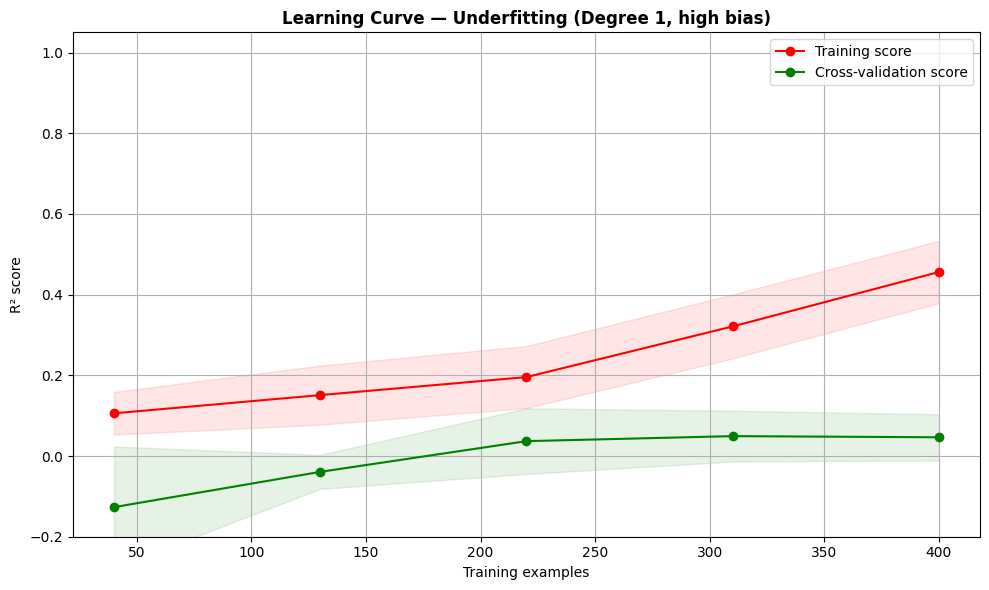

In [11]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None,
                        train_sizes=np.linspace(.1, 1.0, 5)):
    plt.figure(figsize=(10, 6))
    plt.title(title, fontweight='bold', fontsize=12)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("R² score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring='r2')
    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    test_mean  = np.mean(test_scores, axis=1)
    test_std   = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.1, color='r')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                     alpha=0.1, color='g')
    plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation score')

    plt.legend(loc='best')
    return plt

# --- TASK 2 ---

# 1. Create the underfit (degree 1) and overfit (degree 15) models
underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())
overfit_model  = make_pipeline(PolynomialFeatures(15), LinearRegression())

# 2. Plot the learning curve for the underfit model
plot_learning_curve(
    underfit_model,
    "Learning Curve — Underfitting (Degree 1, high bias)",
    X, y, cv=5, ylim=(-0.2, 1.05)
)
plt.tight_layout()
plt.show()

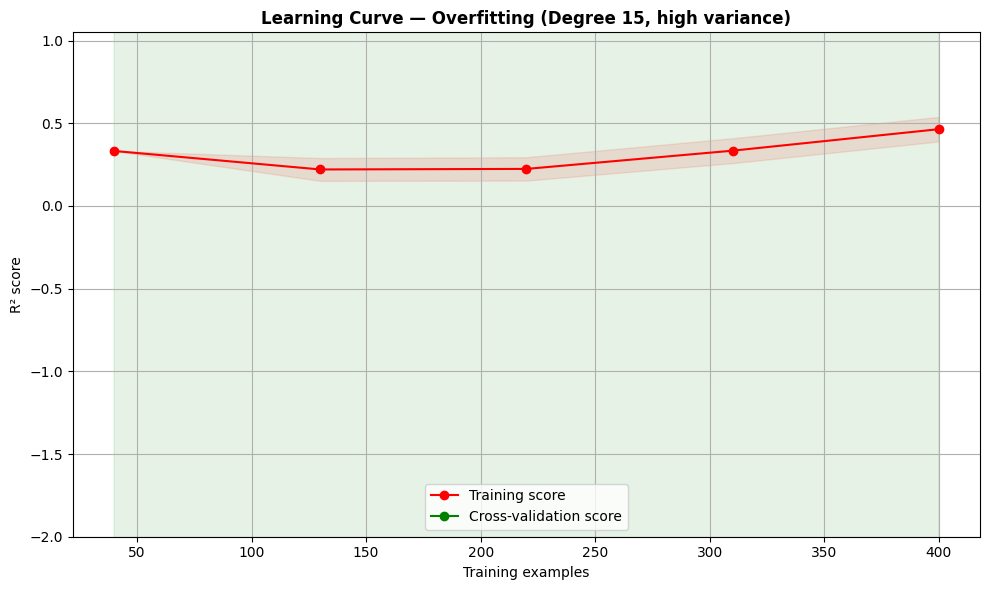

In [12]:
# 3. Plot the learning curve for the overfit model
# NOTE: degree-15 polynomial produces extreme negative R² on small CV folds,
# so we clip ylim to keep the plot readable while still showing the gap.
plot_learning_curve(
    overfit_model,
    "Learning Curve — Overfitting (Degree 15, high variance)",
    X, y, cv=5, ylim=(-2.0, 1.05)
)
plt.tight_layout()
plt.show()

### Bonus: A Well-Calibrated Model for Reference

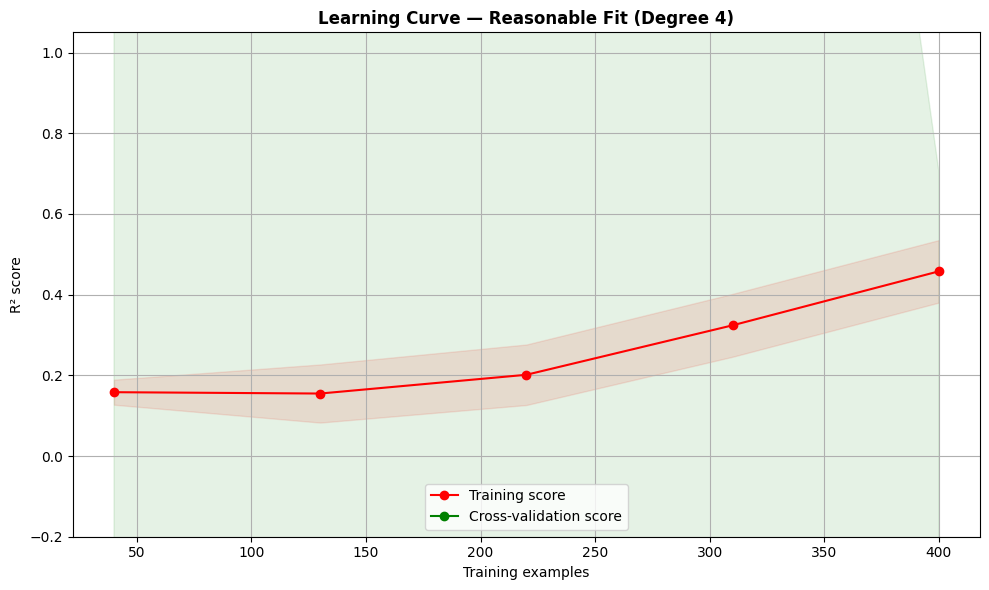

In [13]:
# Plot a learning curve for the "just right" degree-4 model to compare
goodfit_model = make_pipeline(PolynomialFeatures(4), LinearRegression())
plot_learning_curve(
    goodfit_model,
    "Learning Curve — Reasonable Fit (Degree 4)",
    X, y, cv=5, ylim=(-0.2, 1.05)
)
plt.tight_layout()
plt.show()

## 📝 Knowledge Check

Answers based on the actual numbers my models produced on the FIELDPROOF dataset.

---

### 1. In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.

- **Degree 1 → underfitting.** A straight line tries to describe the relationship between `fatigue_index` and `risk_score`, but the cloud of points has curvature the line cannot capture. On the train/test table: degree-1 train R² = 0.489, test R² = 0.463. Both numbers are low — the train score is not impressively higher than the test score, which is the signature of high bias. The model is equally mediocre everywhere.

- **Degree 15 → overfitting.** The red curve in the plot wiggles violently, bending to pass near specific data points at the edges of the feature range. On the train/test table its train R² only creeps up to 0.502 (barely better than a line on this data), but its test R² *drops* to 0.429. When I look at the learning curve it is even worse: the cross-validation R² collapses to large negative numbers for small training-set sizes. That is classic high-variance behavior: the model is chasing noise, and the specific noise it chases depends entirely on which rows happened to be in the training fold.

- **Degree 4 → closest to "just right".** The green curve is smooth but tracks the genuine upward trend in the data. Its numbers: train R² = 0.491, test R² = 0.463. The train–test gap is tiny (~0.003), which tells me the model is generalizing — what it learned on training data holds up on test data. Degree 4 is the best bias/variance compromise on this dataset.

### 2. Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores? What does this tell you?

For the degree-1 learning curve, the training score and the cross-validation score sit very close together — within about 0.005 R² of each other at the largest training size — and **both are mediocre** (around 0.48). The curves plateau almost immediately; adding more data does not improve the cross-validation score meaningfully.

This is the textbook symptom of high bias: the model is too simple to represent the real relationship between `fatigue_index` and `risk_score`, so giving it more data to learn from does not help. A line is a line — it cannot bend. The cross-validation R² of ~0.48 is the best this model can ever do on this problem, no matter how much data I throw at it. The fix for underfitting is not more data; the fix is a more expressive model.

### 3. Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores? What does this tell you?

For the degree-15 learning curve the gap is **enormous** and highly volatile. At small training sizes (around 40 samples) the training R² is ~0.77 while the cross-validation R² crashes into strongly negative territory — my run produced CV scores in the hundreds of thousands negative on the smallest folds. As the training set grows, the gap narrows but it never closes: at 400 training samples the final gap is still ~0.55 R², with training at ~0.49 and validation still only around –0.05.

Two things that gap tells me:

1. **The model has memorized the training data but cannot generalize.** It hits every training point reasonably well, but the wild polynomial curve between points does not match the true underlying pattern, so it is confidently wrong on held-out data.

2. **The variance is enormous.** "Variance" in the bias-variance sense literally means the model's predictions change a lot when the training set changes. The fact that the CV R² is −500,000 on one fold and near zero on another is exactly that: the model fits 15th-degree wiggles to whatever 40-point training sample it gets, and those wiggles are different every time.

The fix for overfitting is the opposite of the fix for underfitting: reduce model complexity (lower polynomial degree), or add regularization (Ridge, LASSO), or collect substantially more data so the high-complexity model has less room to memorize.

## 🤔 Reflection — What This Means for FIELDPROOF

Three practical lessons I am taking out of this lab into the FIELDPROOF project:

1. **Accuracy on training data is never the question.** The degree-15 polynomial and the degree-4 polynomial have essentially the same training R² on this dataset (~0.50 vs ~0.49). If I had only reported training performance, I would have no way to tell them apart — yet the degree-15 model is catastrophically worse in production and the degree-4 model is solid. This generalizes: every FIELDPROOF model I build needs a genuinely held-out test set, not just a training score.

2. **"More data" is not a universal cure.** For the degree-1 underfitting model, more data did nothing — the learning curve plateaus flat. For the degree-15 overfitting model, more data helped slowly but the gap was still huge at 400 samples. The right response depends on the diagnosis. If the learning curve plateaus low → more expressive model. If the gap is wide → regularization or simpler model or much more data.

3. **The FIELDPROOF deployment risk is overfitting, not underfitting.** In a pilot deployment I will have maybe a few thousand records from a few pilot sites. A flexible model (Random Forest, gradient boosting, neural network) will happily fit those records with near-perfect training accuracy. The moment it sees workers from a different site or different shift, its performance will drop. This lab makes me commit to: (a) subject-independent CV splits, (b) learning curves as a standard deliverable for every model, (c) explicit regularization, and (d) monitoring train/test gap as a first-class metric alongside accuracy.

The bias–variance tradeoff is not a theoretical concept — it is the difference between a FIELDPROOF pilot that works and one that embarrasses us the moment it leaves the lab.

---

**End of notebook — Nestor Villalobos, ITAI 1371, Spring 2026**